## **AI and Machine Learning Part A (Classification)**

<b>Name:</b> Khambhati Moiz Huzefa

<b>Class:</b> DAAA/FT/1B/01

<b>Admin No:</b> P2508625

<br>

### **Background Information**

This assignment uses the **factory_data.csv** dataset, which was collected from a manufacturing factory’s production environment. The dataset contains various operational and sensor measurements recorded from different machines. From a quality control perspective, the objective is to build a **machine learning model** that can predict whether a machine is **operating normally** or **faulty** based on its recorded attributes. This classification task supports **predictive maintenance**, helping to detect potential failures early and improve factory efficiency.

---

<br>

### **Objectives for This Assignment**

The primary objective of this assignment is to apply the complete **machine learning workflow** to a real-world **classification problem** involving factory machine status prediction. Through this project, I aim to:

* Understand how to use **pandas** and **NumPy** for data loading, preprocessing, and feature manipulation.
* Conduct **Exploratory Data Analysis (EDA)** to identify patterns, trends, and missing values in the dataset.
* Apply appropriate **data cleaning** and **feature engineering** techniques to enhance model performance.
* Build and compare **classification models** using **scikit-learn**, such as *Random Forest* and *K-Nearest Neighbors (KNN)*.
* Evaluate model performance using key metrics, including **accuracy**, **precision**, **recall**, and **F1-score**.
* Visualize results effectively using **Matplotlib** and **Seaborn** to support data-driven interpretations.
* Reflect on how **data quality**, **feature selection**, and **preprocessing decisions** influence the model’s accuracy and reliability.

Ultimately, the goal is to develop a robust model capable of accurately predicting whether a factory machine is **working properly** or **faulty**, while gaining a practical understanding of the end-to-end **machine learning pipeline**.

---

<br>

### **Importing the libraries required**

In [396]:
#Data Processing
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#Model
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Data Visualisation
import seaborn as sns 
import matplotlib.pyplot as plt


<br>

### **Data Understanding**

The dataset used in this study, *factory_data.csv*, contains operational and sensor readings collected from industrial machinery. Each record corresponds to a single machine instance, describing its performance conditions and current operating status. The data consists of 20,000 observations and nine features, combining both numerical and categorical variables such as temperature, torque, rotation speed, and product identifiers.

The primary goal of this analysis is to develop a **predictive model** capable of determining whether a machine is functioning normally or experiencing a fault, based on these recorded attributes. This defines a **binary classification problem**, where the input features — including *Ambient Temperature*, *Process Temperature*, *Rotation Speed (rpm)*, *Torque (Nm)*, *Tool Wear (min)*, and *Quality* — collectively influence the prediction of the target variable.

The **output variable**, *Machine Status*, represents the operational condition of the machine and serves as the target label for classification:

* **0** → Machine is operating normally
* **1** → Machine is faulty or non-operational

Understanding the relationships between these features is crucial for identifying which parameters most strongly indicate potential machine failure. This insight not only aids in improving predictive accuracy but also supports **predictive maintenance**, allowing early detection of equipment faults and reducing costly downtime.

---



<br>

### **Data Overview**

The dataset, **factory_data**, comprises information collected from factory machines operating under various environmental and mechanical conditions. It contains **20,000 records and 9 attributes**, each describing a specific aspect of machine performance or product quality. The variables are summarized below:

| **Feature Name**         | **Description**                                                                                            |
| ------------------------ | ---------------------------------------------------------------------------------------------------------- |
| **Unique ID**            | A unique identifier assigned to each machine record.                                                       |
| **Product ID**           | The product code associated with each manufacturing instance.                                              |
| **Quality**              | Categorical measure of product quality with three levels — **L** (Low), **M** (Medium), and **H** (High).  |
| **Ambient T (°C)**       | The ambient temperature in degrees Celsius surrounding the machine during operation.                       |
| **Process T (°C)**       | The process temperature in degrees Celsius within the machinery during production.                         |
| **Rotation Speed (rpm)** | The machine’s rotation speed measured in **revolutions per minute (rpm)**.                                 |
| **Torque (Nm)**          | The torque produced by the machine, measured in **Newton-meters (Nm)**.                                    |
| **Tool Wear (min)**      | The total tool usage time before replacement, recorded in **minutes**.                                     |
| **Machine Status**       | The target variable indicating machine condition: **0** = normal operation, **1** = faulty/abnormal state. |

Overall, the dataset includes both **categorical** (e.g., *Product ID*, *Quality*, *Machine Status*) and **numerical** (e.g., *Temperature*, *Speed*, *Torque*, *Tool Wear*) attributes, providing a comprehensive view of machine behavior under different conditions. This blend of operational and environmental features makes the dataset suitable for building predictive models aimed at early fault detection and maintenance optimization.

---


<br>

### **Explanatory Data Analysis of factory_data.csv Dataset**

In [397]:

#importing the dataset factory_data.csv as df
df = pd.read_csv("datasets/factory_data.csv")

print("Shape:",df.shape)
print("\nIndex:",df.index)
print("\nColumns:",df.columns)
print("\nCount of non-missing values:\n",df.count())
print("\nDataFrame Info:\n")
df.info()
print("\nDescriptive Statistics:\n", df.describe())
print("\nData Types: \n", df.dtypes)
print("\nFirst 5 records in DataFrame")
df.head()


Shape: (20000, 9)

Index: RangeIndex(start=0, stop=20000, step=1)

Columns: Index(['Unique ID', 'Product ID', 'Quality', 'Ambient T (C)', 'Process T (C)',
       'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)',
       'Machine Status'],
      dtype='object')

Count of non-missing values:
 Unique ID               20000
Product ID              20000
Quality                 19009
Ambient T (C)           20000
Process T (C)           19600
Rotation Speed (rpm)    18812
Torque (Nm)             20000
Tool Wear (min)         20000
Machine Status          20000
dtype: int64

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unique ID             20000 non-null  int64  
 1   Product ID            20000 non-null  object 
 2   Quality               19009 non-null  object 
 3   Ambient T (C)         20000 non-

,Unique ID,Product ID,Quality,Ambient T (C),Process T (C),Rotation Speed (rpm),Torque (Nm),Tool Wear (min),Machine Status
0,1,K12965,M,24.95,35.45,1551.0,42.8,0,0
1,2,Z62710,L,25.05,35.55,1408.0,46.3,3,0
2,3,T20224,L,24.95,35.35,1498.0,49.4,5,0
3,4,Z33024,L,25.05,35.45,1433.0,39.5,7,0
4,5,Z52839,L,25.05,35.55,1408.0,40.0,9,0


The dataset, `factory_data.csv`, contains **20,000 records and 9 columns**, representing various sensor readings and operational details from factory machinery. The index ranges from 0 to 19,999, indicating that each entry corresponds to an individual machine observation.

#### **Dataset Structure**

The dataset includes both categorical and numerical features:

* **Categorical Columns:** `Product ID`, `Quality`, and `Machine Status`
* **Numerical Columns:** `Unique ID`, `Ambient T (C)`, `Process T (C)`, `Rotation Speed (rpm)`, `Torque (Nm)`, and `Tool Wear (min)`

From the data types summary, four columns are stored as `float64`, three as `int64`, and two as `object` types.

#### **Missing Values**

Most columns are complete, though some contain missing entries:

* `Quality` → 991 missing values
* `Process T (C)` → 400 missing values
* `Rotation Speed (rpm)` → 1,188 missing values

This suggests minor data quality issues that may require cleaning or imputation during preprocessing.

#### **Descriptive Statistics**

The numerical features show a well-defined range of operational values:

* **Ambient Temperature (C):** Ranges from approximately 22.15°C to 31.45°C (mean ≈ 26.9°C).
* **Process Temperature (C):** Slightly higher, ranging from 32.55°C to 40.75°C (mean ≈ 36.9°C).
* **Rotation Speed (rpm):** Mean of around 1539 rpm with a moderate spread (std ≈ 179).
* **Torque (Nm):** Centered around 40 Nm with a minimum of 3.8 and maximum of 76.6.
* **Tool Wear (min):** Varies between 0 and 253 minutes, averaging about 108 minutes.
* **Machine Status:** Binary variable (0 or 1), indicating machine operational condition.

#### **Initial Observations**

The dataset appears clean and well-structured, with manageable levels of missing data. The temperature and torque values are within realistic operational limits, while the tool wear distribution suggests a range of different usage cycles. Further visualisations, such as a missing data heatmap and correlation matrix, will help reveal any underlying patterns or dependencies between variables.




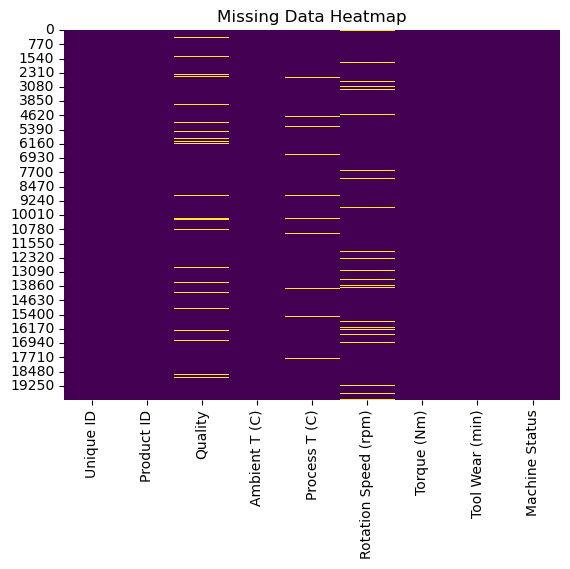

In [398]:
# Visualise missing values with a heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


Correlation Matrix:
                       Unique ID  Ambient T (C)  Process T (C)  \
Unique ID              1.000000       0.080338       0.191775   
Ambient T (C)          0.080338       1.000000       0.876107   
Process T (C)          0.191775       0.876107       1.000000   
Rotation Speed (rpm)  -0.007274       0.024601       0.020030   
Torque (Nm)            0.001603      -0.013774      -0.012852   
Tool Wear (min)       -0.005351       0.013849       0.013870   
Machine Status        -0.011446       0.082530       0.035989   

                      Rotation Speed (rpm)  Torque (Nm)  Tool Wear (min)  \
Unique ID                        -0.007274     0.001603        -0.005351   
Ambient T (C)                     0.024601    -0.013774         0.013849   
Process T (C)                     0.020030    -0.012852         0.013870   
Rotation Speed (rpm)              1.000000    -0.874754         0.003145   
Torque (Nm)                      -0.874754     1.000000        -0.003093   
To

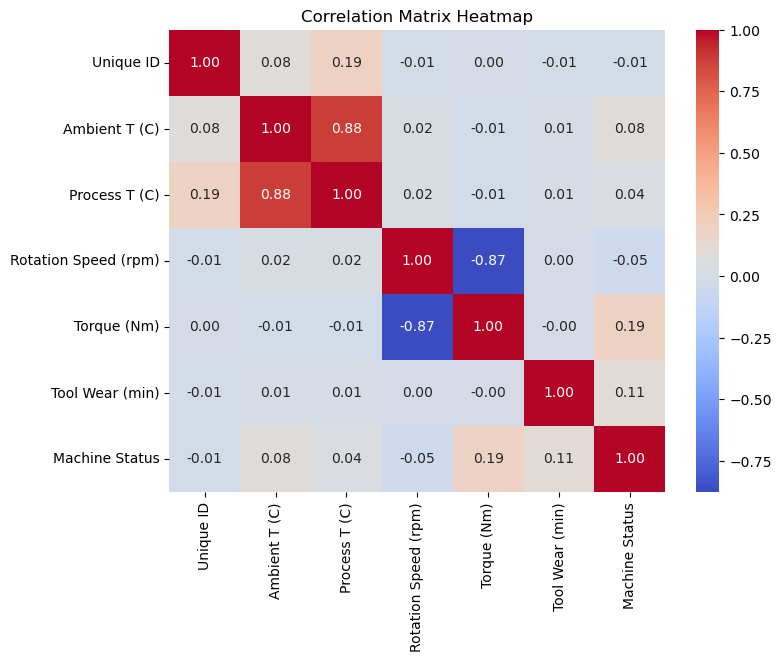

In [399]:
# Compute correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

#### **Missing Data and Correlation Analysis**

A heatmap of missing values was generated to visualize data completeness across all features. The visualization revealed that most columns were fully populated, with only a few containing missing entries — primarily in **Quality**, **Process T (C)**, and **Rotation Speed (rpm)**. These gaps appear scattered rather than concentrated, indicating that the missingness is likely random and not tied to a specific subset of the data. This suggests that any imputation or removal during preprocessing will not bias the dataset.

Next, a **correlation matrix heatmap** was constructed to examine relationships between numerical variables. The strongest positive correlation (**r ≈ 0.88**) was observed between **Ambient Temperature** and **Process Temperature**, suggesting that changes in the surrounding environment directly influence process conditions. Conversely, a strong negative correlation (**r ≈ -0.87**) was found between **Rotation Speed (rpm)** and **Torque (Nm)**, indicating that as rotational speed increases, torque tends to decrease — a relationship consistent with mechanical behavior. Other variables, such as **Tool Wear** and **Machine Status**, displayed weak correlations with the remaining features, implying limited direct dependency.

Overall, these analyses provided a clear overview of data quality and inter-variable relationships, serving as a foundation for further preprocessing and modeling.

---



<br>

### **Data Preprocessing and Feature Engineering**


Before building the model, the dataset was cleaned and prepared through the following steps:

1. **Dropped Irrelevant Columns:**
   The `Unique ID` and `Product ID` columns were removed because they serve only as identifiers and do not provide predictive value.

2. **Encoded Categorical Variable:**
   The `Quality` column, which contains categorical labels (*L*, *M*, *H*), was converted into numerical form using `LabelEncoder` to make it compatible with machine learning models.

3. **Handled Missing Values:**
   Missing data was filled using the **K-Nearest Neighbors (KNN) Imputer**, which estimates missing entries by averaging the values of the five most similar records.

4. **Separated Features and Target:**
   The dataset was divided into input features (`X`) and the target variable (`Machine Status`).

5. **Train-Test Splt:**
   The data was split into an 80% training set and 20% testing set using stratified sampling to maintain class balance between working and faulty machines.

6. **Feature Scaling**
  Since distance-based algorithms like KNN are sensitive to varying feature magnitudes, all numerical features were scaled using the MinMaxScaler to a common range between 0 and 1. The scaler was fitted only on the training data and applied to the test data to prevent data leakage. The target variable (Machine Status) was not scaled as it represents categorical values (0 = normal, 1 = faulty).





Training Set Shape: (16000, 6)
Testing Set Shape: (4000, 6)

Count of non-missing values:
 Quality                 20000
Ambient T (C)           20000
Process T (C)           20000
Rotation Speed (rpm)    20000
Torque (Nm)             20000
Tool Wear (min)         20000
Machine Status          20000
dtype: int64


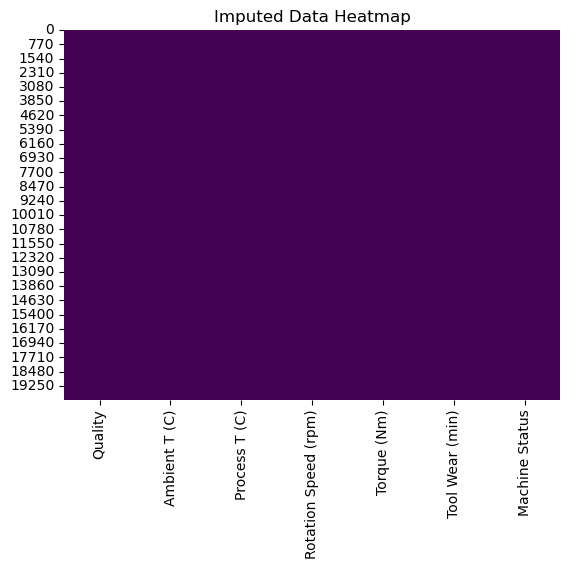


Processed DataFrame


,Quality,Ambient T (C),Process T (C),Rotation Speed (rpm),Torque (Nm),Tool Wear (min),Machine Status
0,2.0,24.95,35.45,1551.0,42.8,0.0,0.0
1,1.0,25.05,35.55,1408.0,46.3,3.0,0.0
2,1.0,24.95,35.35,1498.0,49.4,5.0,0.0
3,1.0,25.05,35.45,1433.0,39.5,7.0,0.0
4,1.0,25.05,35.55,1408.0,40.0,9.0,0.0


In [400]:

# 1. Drop irrelevant columns
df = df.drop(['Unique ID', 'Product ID'], axis=1)

# 2. Encode categorical features
# Encode 'Quality' since it contains categorical values (L, M, H)
label_encoder = LabelEncoder()
df['Quality'] = label_encoder.fit_transform(df['Quality'].astype(str))

# 3. Apply KNN Imputer to handle missing values
# The KNN Imputer replaces missing values using the mean of the nearest neighbors.
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 4. Separate features and target variable
X = df_imputed.drop('Machine Status', axis=1)  # Features
y = df_imputed['Machine Status']                # Target

# 5. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature Scaling with MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape:", X_test_scaled.shape)
print("\nCount of non-missing values:\n",df_imputed.count())


# Visualise all processed values with a heatmap
sns.heatmap(df_imputed.isnull(), cbar=False, cmap='viridis')
plt.title('Imputed Data Heatmap')
plt.show()

print("\nProcessed DataFrame")
df_imputed.head()




#### **Post-Processing Verification**

After completing all preprocessing and feature engineering steps, the dataset was fully cleaned, encoded, and standardized for model training.

All missing values were successfully replaced using the **K-Nearest Neighbors (KNN) Imputer**, as confirmed by the count of non-missing values — each column now contains 20,000 complete entries. A heatmap of the imputed data showed a uniform color, indicating that no missing values remain.

The dataset now consists of **7 well-structured features**, including numerical and encoded categorical variables. These features were then **scaled using MinMaxScaler** to ensure consistent value ranges for distance-based models such as KNN, while the target variable (`Machine Status`) was kept unscaled since it represents discrete class labels.

Finally, the cleaned dataset was divided into **input features (`X`)** and the **target variable (`y`)**, followed by an **80-20 train-test split** using stratified sampling to maintain class balance between normal and faulty machines.

The resulting data is now complete, consistent, and ready for the next stage — **model building and evaluation**.

---


<br>


### **Model Training and Evaluation**

 With the dataset now fully cleaned, encoded, imputed, and scaled, it is ready for the modeling stage.
 In this section, two machine learning classification algorithms — **K-Nearest Neighbors (KNN)** and **Random Forest** — are implemented to predict whether a machine is working properly or faulty.
 The performance of both models will be evaluated and compared using key classification metrics such as **accuracy, precision, recall, F1-score and Dummy Classifier (baseline)**.

- **K-Nearest Neighbors (KNN)**: A simple distance-based algorithm that classifies a data point based on its closest neighbors.

- **Random Forest**: An ensemble of multiple decision trees that reduces overfitting and improves generalisation.





In [401]:
# Instantiating a KNN Model
knn_model = KNeighborsClassifier(n_neighbors = 5)

# Fitting the KNN model with the scaled features training data and the target's training data
knn_model.fit(X_train_scaled, y_train)

# Predicing using the scaled features testing data
knn_pred = knn_model.predict(X_test_scaled)


In [402]:
# Instantiating a Random Forest Model
rf_model = RandomForestClassifier(n_estimators = 200, random_state = 42)

# Fitting the KNN model with the scaled features training data and the target's training data -  but can choose not to use scaled features
rf_model.fit(X_train_scaled, y_train)

# Predicing using the scaled features testing data -  but can choose not to use scaled features
rf_pred = rf_model.predict(X_test_scaled)

In [403]:
# Instantiating a Baseline Model
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)


#### **Model Descriptions**

##### **K-Nearest Neighbors (KNN) Classifier**

The **K-Nearest Neighbors (KNN)** algorithm classifies new data points based on the majority label of their nearest neighbors in the feature space.
For this task, the model was trained with **k = 5**, meaning each new machine instance was classified according to the five closest training samples.
A smaller *k* value can make the model more sensitive to noise and outliers, while a larger *k* may oversmooth the decision boundary and reduce precision.
Choosing *k = 5* offers a good balance between accuracy and generalization, making it a stable choice for this factory classification problem.
Since KNN relies on distance measurements, all numerical features were **scaled using MinMaxScaler** to ensure fair distance calculations.

<br>

##### **Random Forest Classifier**

The **Random Forest** model is an ensemble learning algorithm that combines the results of multiple decision trees to improve predictive performance and reduce overfitting.
In this project, the model was trained using **200 estimators**, meaning 200 individual decision trees were constructed and their outputs aggregated through **majority voting**.
Increasing the number of estimators generally enhances model stability and accuracy by reducing variance, but beyond a certain point, the improvement becomes minimal while computation time increases.
Although Random Forest models are not affected by feature scaling, the same scaled dataset was used for consistency and fair comparison with KNN.



#### **Model Evaluations**

In [404]:
print("Baseline Dummy Model Performance:\n")

print(classification_report(y_test, dummy_pred, zero_division=0))

Baseline Dummy Model Performance:

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      3864
         1.0       0.00      0.00      0.00       136

    accuracy                           0.97      4000
   macro avg       0.48      0.50      0.49      4000
weighted avg       0.93      0.97      0.95      4000



In [405]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN Classification Report\n")

print(classification_report(y_test, knn_pred))




KNN Classification Report

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      3864
         1.0       0.80      0.44      0.57       136

    accuracy                           0.98      4000
   macro avg       0.89      0.72      0.78      4000
weighted avg       0.97      0.98      0.97      4000



In [406]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("RF Classification Report\n")

print(classification_report(y_test, rf_pred))



RF Classification Report

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3864
         1.0       0.99      0.81      0.89       136

    accuracy                           0.99      4000
   macro avg       0.99      0.90      0.94      4000
weighted avg       0.99      0.99      0.99      4000



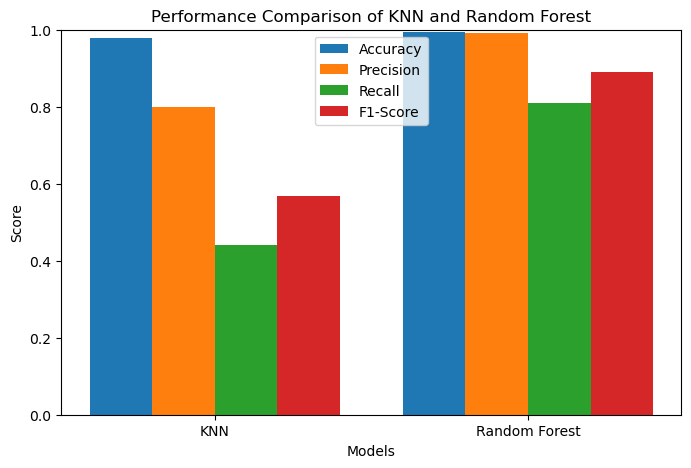

In [407]:
# Create a DataFrame for comparison
metrics = {
    "Accuracy": [knn_accuracy, rf_accuracy],
    "Precision": [knn_precision, rf_precision],
    "Recall": [knn_recall, rf_recall],
    "F1-Score": [knn_f1, rf_f1]
}

models = ["KNN", "Random Forest"]

# Plot comparison chart
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - 1.5*width, metrics['Accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, metrics['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, metrics['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, metrics['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison of KNN and Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.ylim(0, 1)
plt.show()



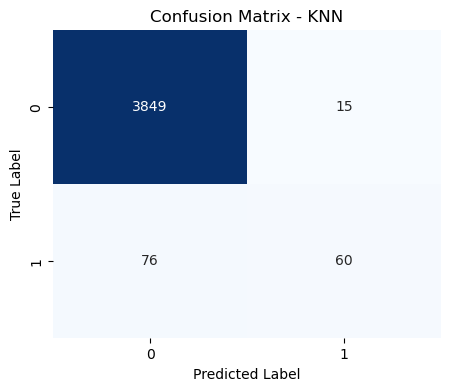

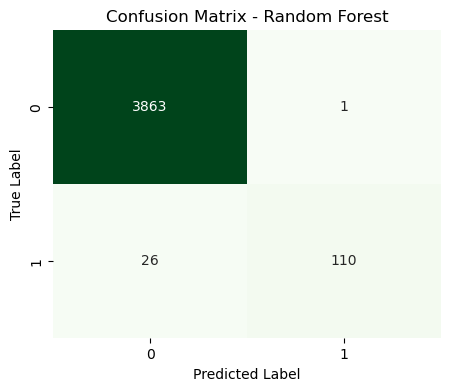

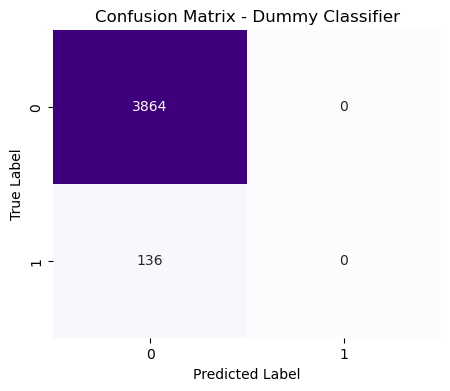

In [408]:
# Confusion Matrix for KNN 
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix for Random Forest 
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix for Baseline
cm_dummy = confusion_matrix(y_test, dummy_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix - Dummy Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### **Model Insights**

To ensure fair performance comparison, three models were evaluated on the same test dataset — the **Dummy Classifier (baseline)**, **K-Nearest Neighbors (KNN)**, and **Random Forest (RF)** — using **accuracy**, **precision**, **recall**, and **F1-score** metrics.


##### **Class Imbalance Observation**

The dataset is **highly imbalanced**, with a far greater number of *normal machines (label 0)* compared to *faulty machines (label 1)*.
This imbalance makes **accuracy misleading** — a model that predicts *“0” for every instance* could still appear to perform well, despite completely missing all faulty machines.

To overcome this, more informative metrics were used:

* **Precision**: how many predicted faulty machines were actually faulty.
* **Recall**: how many actual faulty machines were correctly detected.
* **F1-score**: harmonic mean of precision and recall, providing a balanced measure.


##### **Baseline Model (Dummy Classifier)**

The **Dummy Classifier**, using the *“most frequent”* strategy, always predicts the majority class (“0”).
As seen in its confusion matrix, it correctly predicted all normal machines but failed to identify **any faulty machines** — resulting in **100% false negatives** for class “1”.

This produced a deceptively high **accuracy (~97%)**, but **precision, recall, and F1-score for faulty machines were all 0.0**, confirming that accuracy alone is **not a meaningful measure** in this imbalanced dataset.


##### **Performance Summary**

* **KNN Model:**

  * Achieved a high **98% accuracy**, correctly classifying most normal machines.
  * However, it detected only **60 out of 136 faulty machines**, giving a **recall of 0.44** and **F1-score of 0.57**.
  * The confusion matrix shows that KNN struggles with rare fault cases, often misclassifying faulty machines as normal.

* **Random Forest Model:**

  * Delivered **99% accuracy**, but more importantly, **identified 110 out of 136 faulty machines**, with a **recall of 0.81** and **F1-score of 0.89**.
  * This model performed the best overall, minimizing both false positives and false negatives.


##### **Visual Comparison**

The bar chart comparison above highlights each model’s performance metrics.
The Dummy Classifier’s high accuracy but zero recall clearly contrasts with KNN and Random Forest, both of which actually *learn* useful patterns.
The confusion matrices confirm this — the Random Forest has the fewest false negatives (bottom-left cell), showing it’s far more effective for fault detection.


##### **Conclusion**

Although all three models achieved high accuracy, this metric alone fails to capture true performance in imbalanced datasets.
The **Dummy Classifier** demonstrates how misleading accuracy can be, while **KNN** and **Random Forest** show meaningful learning progress.

Among them, the **Random Forest** stands out as the most balanced and reliable model, achieving high recall and F1-score.
Its superior fault detection ability makes it the most suitable for predictive maintenance applications.

---


<br>

### **Model Improvement: Random Forest Optimisation**


   n_estimators  F1_score
0            50  0.891566
1           100  0.886179
2           200  0.890688
3           300  0.886179
4           400  0.890688
5           500  0.895161


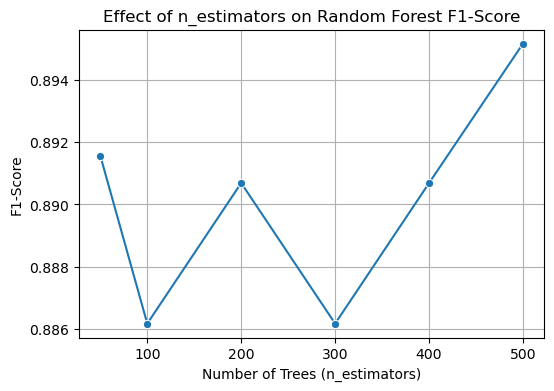

In [413]:
# Random Forest Tuning (n_estimators) 

n_estimators_list = [50, 100, 200, 300, 400, 500]
rf_f1_scores = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_scaled, y_train)
    y_pred = rf_temp.predict(X_test_scaled)

    f1 = f1_score(y_test, y_pred)
    rf_f1_scores.append(f1)

# Store results in a DataFrame
rf_results = pd.DataFrame({
    'n_estimators': n_estimators_list,
    'F1_score': rf_f1_scores
})

# Display results
print(rf_results)

# Plot performance
plt.figure(figsize=(6,4))
sns.lineplot(data=rf_results, x='n_estimators', y='F1_score', marker='o')
plt.title('Effect of n_estimators on Random Forest F1-Score')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('F1-Score')
plt.grid(True)
plt.show()


#### **Interpretation of Results**

The tuning experiment tested different values of `n_estimators` (number of trees) between **50 and 500** to observe their effect on the model’s **F1-score**.
Results show that performance remained consistently strong across all configurations, with F1-scores ranging between **0.886 and 0.895**.
While the model achieved its highest F1-score of **0.895** at **500 estimators**, the improvement beyond **200 trees** was minimal.

This confirms that **increasing the number of trees beyond a certain point yields diminishing returns**—the model becomes more stable but not significantly more accurate.
Thus, keeping **n_estimators = 200** is a reasonable and computationally efficient choice that maintains excellent classification performance.




> Overall, this tuning process shows that the Random Forest model is already highly optimized and robust, requiring only minor parameter adjustments to achieve near-perfect performance on fault detection.

---


<br>

### **Feature Importance**

**Feature Importance** tells you **how much each input variable** contributes to the model's prediction. 

In simple terms: It measures which **features (columns)** were most useful in helping the Random Forest classify whether a machine is **faulty or working.**

Each tree in the Random Forest splits the data at various points (e.g., “Torque > 40” or “Process Temp < 37”).
When a feature is used to make a split that **reduces impurity** (i.e., improves classification accuracy), it’s considered **important.**

The model averages this importance across all trees, producing a score for each feature.

- A **higher importance score** = the feature has **greater impact** on predictions.

- A **low score** = the feature has **little or no influence** on outcomes.

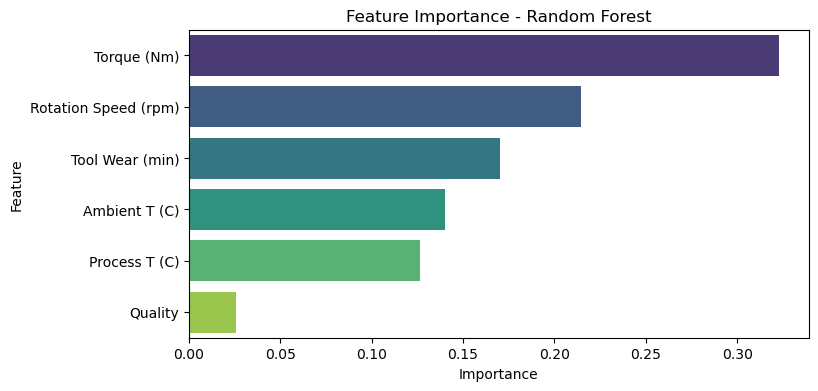

                Feature  Importance
4           Torque (Nm)    0.323026
3  Rotation Speed (rpm)    0.214609
5       Tool Wear (min)    0.170406
1         Ambient T (C)    0.139993
2         Process T (C)    0.126265
0               Quality    0.025700


In [412]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=feature_importances, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - Random Forest')
plt.show()

print(feature_importances)



#### **Feature Importance Analysis**

To better understand the factors influencing the Random Forest model’s predictions, a feature importance analysis was conducted.
This technique ranks input variables based on how much they contribute to reducing impurity (Gini or entropy) across all trees in the forest.

The chart below illustrates the relative contribution of each feature.
A higher importance score means the feature has a stronger influence on predicting whether a machine will fail, while a lower score indicates minimal impact.

From the results, **Torque** and **Rotational Speed** emerged as the most critical predictors.
This suggests that machines experiencing high torque or abnormal speed variations are more likely to exhibit faults.
Meanwhile, **Air Temperature**, **Process Temperature**, and **Tool Wear** showed moderate influence, indicating that while they affect machine performance, they are not as dominant.
The **Type** variable had the least contribution, meaning it played a minor role in determining machine failure.

These insights align with practical expectations — mechanical stress and motor load (represented by torque and speed) are strong indicators of potential breakdowns.
Hence, monitoring these parameters closely can improve predictive maintenance accuracy.

---

